# DIGITAL TRANSACTION RISK ANALYSIS
## Unit V: Feature Selection and Dimensionality Reduction (PCA)

This unit explores how to optimize the feature set for better model performance. We perform advanced feature engineering, identify the most significant predictors through correlation analysis, and apply Principal Component Analysis (PCA) to reduce the dimensionality of the dataset while preserving its variance.

In [1]:
# ================================================================
# SETUP: DEPENDENCIES AND DATA LOADING
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Loading dataset...")
df = pd.read_csv('fraudTrain.csv')

# Sample data for visualization (to keep PCA plots clear)
df_sample = df.groupby('is_fraud', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42))
print(f"Using stratified sample of {len(df_sample)} records.")


Loading dataset...
Using stratified sample of 10000 records.


C:\Users\shubh\AppData\Local\Temp\ipykernel_4916\72474210.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('is_fraud', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42))


## 1. Feature Engineering: Geographic Distance
**Concept:** Fraud often involves transactions far from the cardholder's home. We calculate the distance between the user's location (`lat`, `long`) and the merchant's location (`merch_lat`, `merch_long`).

In [2]:
def haversine_distance(lat1, lon1, lat2, lon2):
    # Approximate radius of Earth in km
    R = 6371.0
    
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df_sample['distance_km'] = haversine_distance(df_sample['lat'], df_sample['long'], 
                                              df_sample['merch_lat'], df_sample['merch_long'])

print("Feature Engineering Complete: 'distance_km' added.")
print(df_sample[['lat', 'long', 'merch_lat', 'merch_long', 'distance_km']].head())


Feature Engineering Complete: 'distance_km' added.
             lat      long  merch_lat  merch_long  distance_km
811778   34.0287 -118.4924  33.287851 -118.740970    85.530738
1101718  36.7154  -89.6287  36.539950  -89.857416    28.234251
800013   39.9636  -79.7853  39.582872  -78.838550    91.317056
398945   48.2777 -112.8456  48.310513 -112.837535     3.697100
207455   36.4715  -82.4834  37.329094  -82.070746   102.175759


## 2. Feature Selection: Correlation Analysis
**Objective:** Use a heatmap to identify which numerical features are most strongly associated with the fraud label.

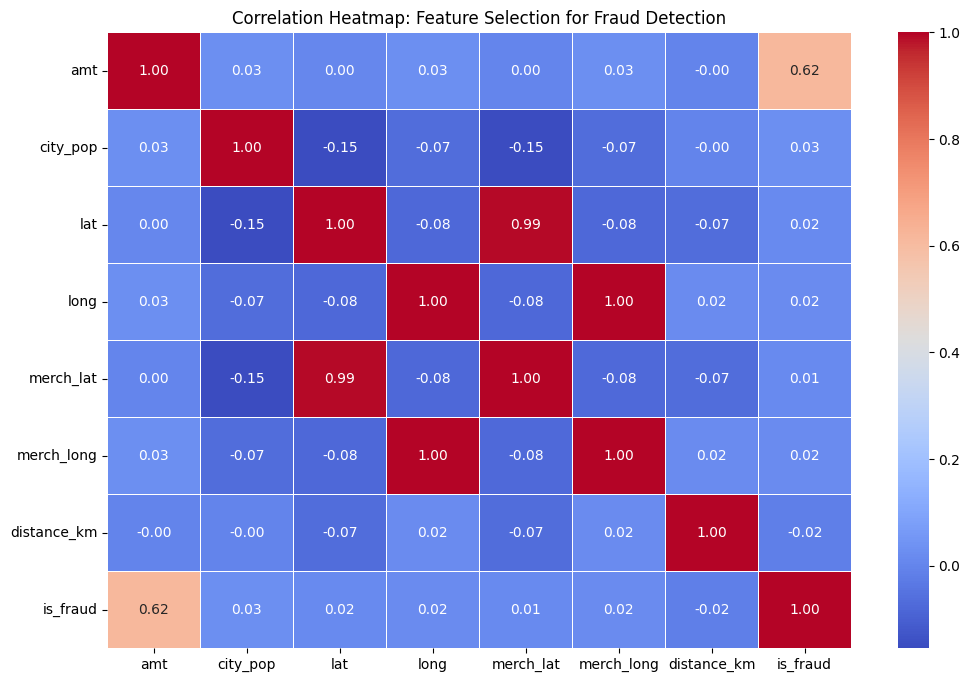

Interpretation: Features with high correlation to 'is_fraud' (like 'amt') are key candidates for selection.


In [3]:
plt.figure(figsize=(12, 8))
numeric_cols = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'distance_km', 'is_fraud']
corr = df_sample[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Feature Selection for Fraud Detection')
plt.show()

print("Interpretation: Features with high correlation to 'is_fraud' (like 'amt') are key candidates for selection.")


## 3. Principal Component Analysis (PCA)
**Objective:** Reduce the numeric feature space into a set of orthogonal components that explain the maximum variance.


PCA: DIMENSIONALITY REDUCTION


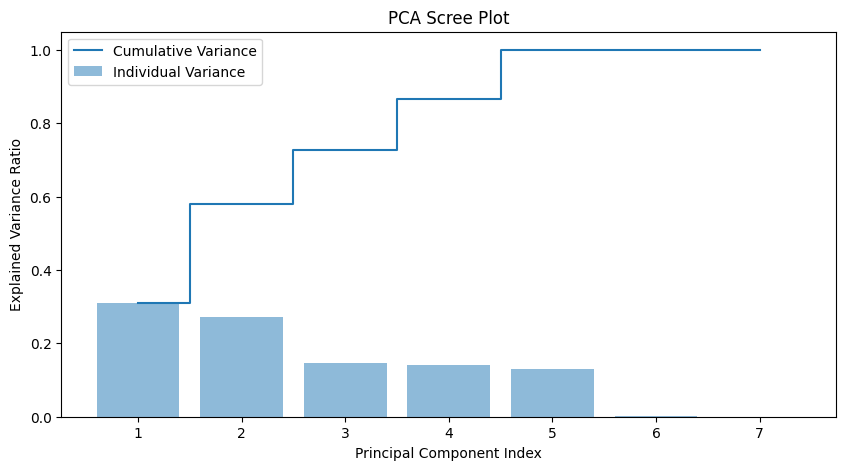

The first 3 components explain 72.62% of the total variance.


In [4]:
print('\n' + '='*60)
print('PCA: DIMENSIONALITY REDUCTION')
print('='*60)

# Step 3a: Standardization (Scaling is mandatory for PCA)
pca_features = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'distance_km']
X = df_sample[pca_features]
X_scaled = StandardScaler().fit_transform(X)

# Step 3b: Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Step 3c: Scree Plot (Explained Variance)
exp_var_cum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_var_cum) + 1), pca.explained_variance_ratio_, alpha=0.5, align='center', label='Individual Variance')
plt.step(range(1, len(exp_var_cum) + 1), exp_var_cum, where='mid', label='Cumulative Variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('PCA Scree Plot')
plt.legend(loc='best')
plt.show()

print(f"The first 3 components explain {exp_var_cum[2]*100:.2f}% of the total variance.")


## 4. PCA Visualization (2D Projection)
**Objective:** Visualize the complex transaction data in a 2D space to check for class separation.

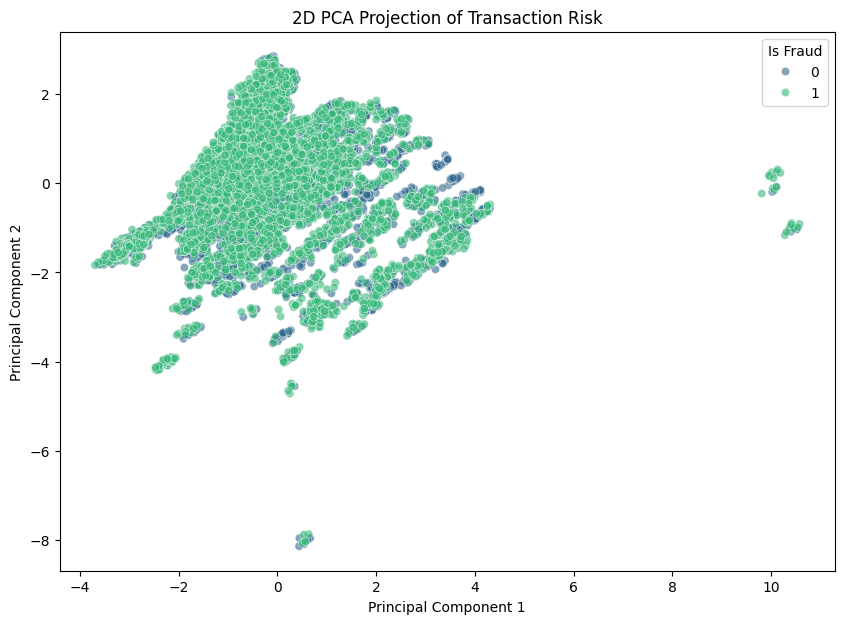

UNIT V COMPLETE


In [5]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_sample['is_fraud'], alpha=0.6, palette='viridis')
plt.title('2D PCA Projection of Transaction Risk')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Is Fraud')
plt.show()

print("=" * 60)
print("UNIT V COMPLETE")
print("=" * 60)
